In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("superstore.csv")

In [19]:
print("First 5 Rows:")
print(df.head())

First 5 Rows:
          Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market  记录数               Order.Date        Order.ID  ... Sales  \
0       0.0     US    1  2011-01-07 00:00:00.000  CA-2011-130813  ...    19   
1       0.0     US    1  2011-01-21 00:00:00.000  CA-2011-148614  ...    19   
2       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...    21   
3       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...   111   
4       0.0     US    1  2011-09-29 00:00:00.000  CA-2011-146969  ...     6   

    Segment                Shi

In [20]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           

In [21]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
           Discount      记录数        Profit      Quantity       Row.ID  \
count  51290.000000  51290.0  51290.000000  51290.000000  51290.00000   
mean       0.142908      1.0     28.610982      3.476545  25645.50000   
std        0.212280      0.0    174.340972      2.278766  14806.29199   
min        0.000000      1.0  -6599.978000      1.000000      1.00000   
25%        0.000000      1.0      0.000000      2.000000  12823.25000   
50%        0.000000      1.0      9.240000      3.000000  25645.50000   
75%        0.200000      1.0     36.810000      5.000000  38467.75000   
max        0.850000      1.0   8399.976000     14.000000  51290.00000   

              Sales  Shipping.Cost          Year       weeknum  
count  51290.000000   51290.000000  51290.000000  51290.000000  
mean     246.498440      26.375818   2012.777208     31.287112  
std      487.567175      57.296810      1.098931     14.429795  
min        0.000000       0.002000   2011.000000      1.0000

In [22]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [23]:
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

In [24]:
print("\nMissing Values After Treatment:")
print(df.isnull().sum())


Missing Values After Treatment:
Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [25]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after removal: {df.duplicated().sum()}")


Number of duplicate rows: 0
Duplicates after removal: 0


In [26]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print("\nUpdated Column Names:")
print(df.columns.tolist())


Updated Column Names:
['category', 'city', 'country', 'customer.id', 'customer.name', 'discount', 'market', '记录数', 'order.date', 'order.id', 'order.priority', 'product.id', 'product.name', 'profit', 'quantity', 'region', 'row.id', 'sales', 'segment', 'ship.date', 'ship.mode', 'shipping.cost', 'state', 'sub.category', 'year', 'market2', 'weeknum']


In [27]:
if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(df["order_date"])
if "ship_date" in df.columns:
    df["ship_date"] = pd.to_datetime(df["ship_date"])

In [28]:
print("\nFinal Dataset Shape:", df.shape)


Final Dataset Shape: (51290, 27)


In [29]:
output_file = "cleaned_superstore.csv"
df.to_csv(output_file, index=False)
print(f"\nData Cleaning Completed! Saved as '{output_file}'")


Data Cleaning Completed! Saved as 'cleaned_superstore.csv'


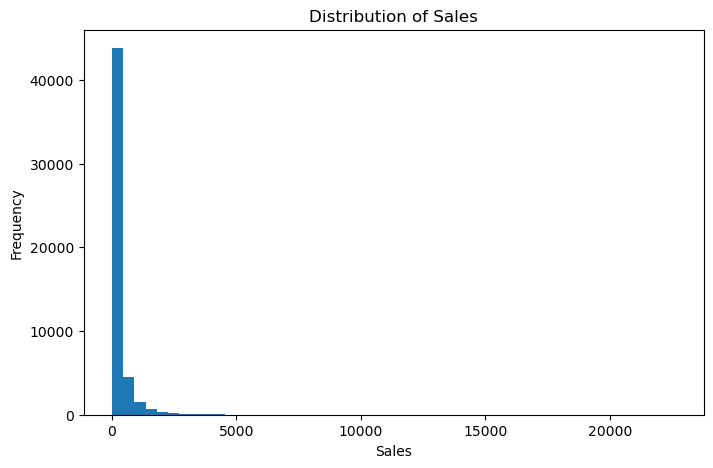

In [30]:
# 1️⃣ Sales Distribution
plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=50)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

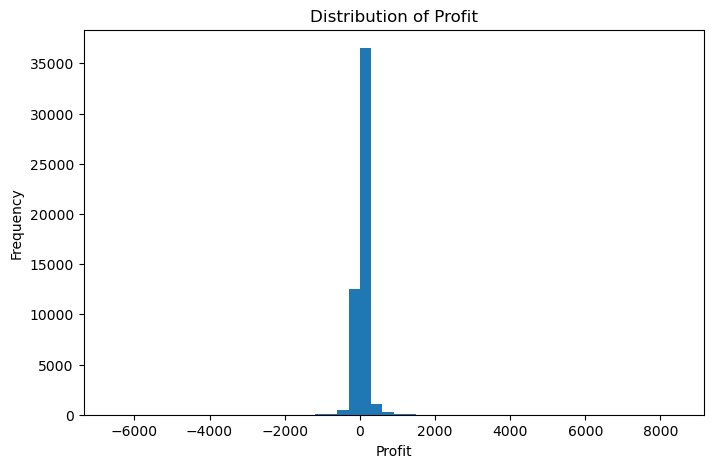

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["profit"], bins=50)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

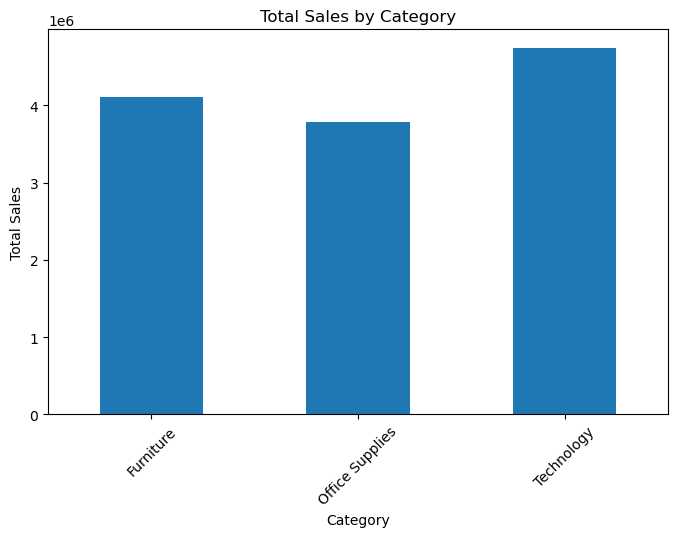

In [32]:
plt.figure(figsize=(8,5))
category_sales = df.groupby("category")["sales"].sum()
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

<Figure size 800x500 with 0 Axes>

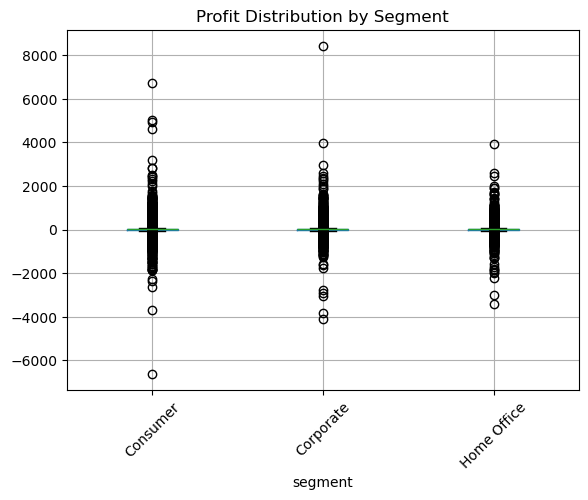

In [33]:
plt.figure(figsize=(8,5))
df.boxplot(column="profit", by="segment")
plt.title("Profit Distribution by Segment")
plt.suptitle("")  # Removes default subtitle
plt.xticks(rotation=45)
plt.show()

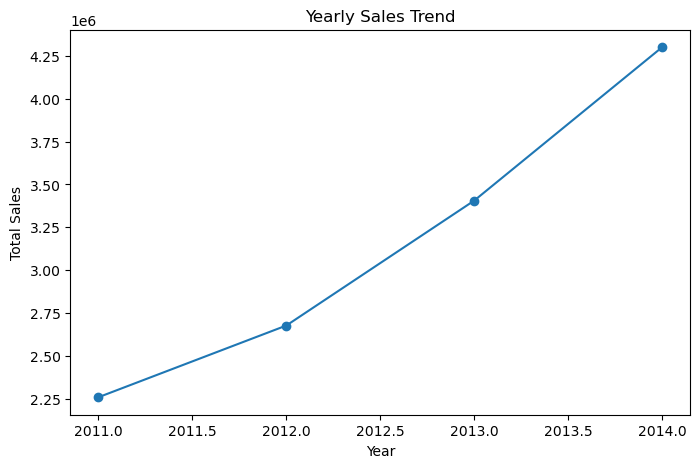

In [34]:
if "year" in df.columns:
    plt.figure(figsize=(8,5))
    yearly_sales = df.groupby("year")["sales"].sum()
    yearly_sales.plot(marker="o")
    plt.title("Yearly Sales Trend")
    plt.xlabel("Year")
    plt.ylabel("Total Sales")
    plt.show()

/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24405 (\N{CJK UNIFIED IDEOGRAPH-5F55}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


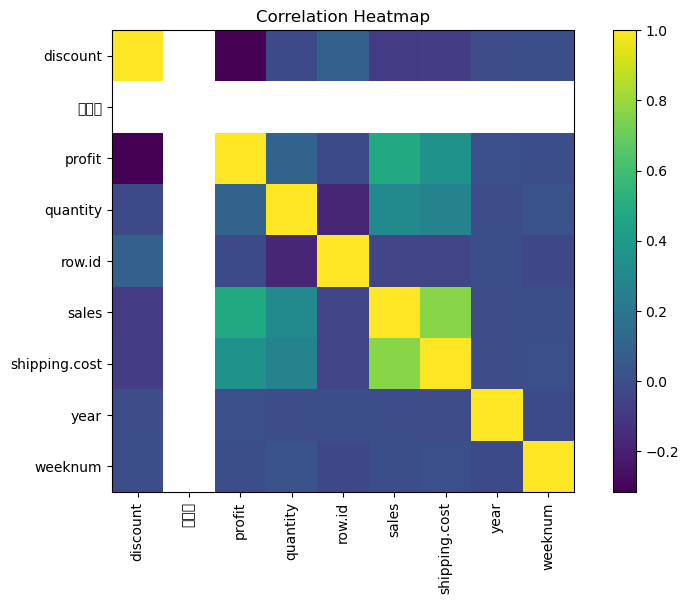

In [35]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=np.number).corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [36]:

print("✅ Visualization Completed!")

✅ Visualization Completed!
